In [4]:
from transformers import pipeline
import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings('ignore')

print("Descargando e inicializando FinBERT ...")

# Silenciamos el aviso específico del "HF_TOKEN" de Hugging Face
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

# Silenciar la librería Transformers(solo nos mostrará en caso de Error Grave)
hf_logging.set_verbosity_error()

# Cargamos un modelo pre-entrenado FinBERT
# Le especificamos que queremos la tarea de "análisis de sentimiento"
analizador_sentimiento = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# Creamos unos titulares de prueba (le hemos puesto una trampa de un titular, el que está en español es una traducción directa del segundo titular)
titulares = [
    "Apple's revenue grew by 20% in the last quarter, beating all market expectations and driving the stock up.",
    "The company is facing a severe liquidity crisis, massive layoffs, and might declare bankruptcy soon.",
    "The central bank kept interest rates unchanged this month following the scheduled meeting.",
    "La empresa se enfrenta a una grave crisis de liquidez y a despidos masivos, y es posible que se declare en quiebra en breve."
]

# Ponemos a la IA a leer y clasificar
resultados = analizador_sentimiento(titulares)

# Mostramos el diagnóstico
print("\n--- DIAGNÓSTICO DEL MERCADO ---\n")
for titular, resultado in zip(titulares, resultados):
    print(f" Titular: {titular}")
    print(f" Sentimiento: {resultado['label'].upper()} (Certeza: {resultado['score'] * 100:.1f}%\n)")

c:\Users\jorge\OneDrive - Universidad Alfonso X el Sabio\Escritorio\Mastering_Financial_DS\nlp-financial-sentiment\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando e inicializando FinBERT ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 19640.65it/s]



--- DIAGNÓSTICO DEL MERCADO ---

 Titular: Apple's revenue grew by 20% in the last quarter, beating all market expectations and driving the stock up.
 Sentimiento: POSITIVE (Certeza: 95.4%
)
 Titular: The company is facing a severe liquidity crisis, massive layoffs, and might declare bankruptcy soon.
 Sentimiento: NEGATIVE (Certeza: 96.4%
)
 Titular: The central bank kept interest rates unchanged this month following the scheduled meeting.
 Sentimiento: NEUTRAL (Certeza: 60.4%
)
 Titular: La empresa se enfrenta a una grave crisis de liquidez y a despidos masivos, y es posible que se declare en quiebra en breve.
 Sentimiento: POSITIVE (Certeza: 67.8%
)


# Conclusión de la trampa: 
Al ser un modelo únicamente entrenado con textos en inglés no ha sabido interpretar el titular en español y me ha dado un resultado al azar. Podemos verlo porque siendo el mismo que el segundo titular que nos indicaba que era negativo en una certeza del 96.40%, en español nos está diciendo que es positivo al 67.80%. 

¿Cómo podemos corregir esto? 

### Código añadiendo traductor

In [5]:
# Instalamos el traductor(deep-translate)
from transformers import pipeline
from deep_translator import GoogleTranslator

# Cargamos el modelo (El original de habla inglesa)
analizador_sentimiento = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# Traductor automático (De cualquier idioma al inglés)
traductor = GoogleTranslator(source='auto', target='en')

# Titulares de prueba (con la trampa)
titulares = [
    "Apple's revenue grew by 20% in the last quarter, beating all market expectations and driving the stock up.",
    "The company is facing a severe liquidity crisis, massive layoffs, and might declare bankruptcy soon.",
    "The central bank kept interest rates unchanged this month following the scheduled meeting.",
    "La empresa se enfrenta a una grave crisis de liquidez y a despidos masivos, y es posible que se declare en quiebra en breve.",
    "El Banco Central Europeo mantiene los tipos de interés sin cambios tras la reunión de hoy."
]

print("\n--- DIAGNÓSTICO MULTILINGÜE DEL MERCADO ---\n")

for titular in titulares:
    # Primero: Traducimos al inglés por debajo del capó
    titular_en_ingles = traductor.translate(titular)
    
    # Segundo: FinBERT analiza la versión en inglés
    resultado = analizador_sentimiento(titular_en_ingles)[0]
    
    print(f" Original: {titular}")
    print(f" Traducido para la IA: {titular_en_ingles}")
    print(f" Sentimiento: {resultado['label'].upper()} (Certeza: {resultado['score'] * 100:.1f}%)\n")
    print("-" * 50)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 27522.94it/s]



--- DIAGNÓSTICO MULTILINGÜE DEL MERCADO ---

 Original: Apple's revenue grew by 20% in the last quarter, beating all market expectations and driving the stock up.
 Traducido para la IA: Apple's revenue grew by 20% in the last quarter, beating all market expectations and driving the stock up.
 Sentimiento: POSITIVE (Certeza: 95.4%)

--------------------------------------------------
 Original: The company is facing a severe liquidity crisis, massive layoffs, and might declare bankruptcy soon.
 Traducido para la IA: The company is facing a severe liquidity crisis, massive layoffs, and might declare bankruptcy soon.
 Sentimiento: NEGATIVE (Certeza: 96.4%)

--------------------------------------------------
 Original: The central bank kept interest rates unchanged this month following the scheduled meeting.
 Traducido para la IA: The central bank kept interest rates unchanged this month following the scheduled meeting.
 Sentimiento: NEUTRAL (Certeza: 60.4%)

------------------------------

# Cotejo del modelo con noticia reales de TESLA (TSLA)
### WebScraping

In [6]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# Definimos el "Ticker" de la empresa que queremos investigar
ticker_empresa = "TSLA"     # Tesla
print(f" Conectando con el mercado para buscar noticias de {ticker_empresa}...")

# Creamos el objeto de la empresa en yfinance
empresa = yf.Ticker(ticker_empresa)

# Descarga de las noticias más recientes (por defecto salen entre 8 y 10 noticias)
noticias_brutas = empresa.news

# Extraemos solo lo que nos interesa (Titular, Fecha y Enlace)
lista_noticias = []
for noticia in noticias_brutas:
    # Usamos .get() para evitar KeyErrors si Yahoo cambia los nombres
    titular = noticia.get('title', 'Titular no disponible')
    enlace = noticia.get('link', 'Enlace no disponible')
    
    # Manejamos la fecha con cautela
    timestamp = noticia.get('providerPublishTime')
    if timestamp:
        fecha = datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d %H:%M:%S')
    else:
        fecha = "Fecha desconocida"
    
    lista_noticias.append({
        'Fecha': fecha,
        'Titular': titular,
        'Enlace': enlace
    })
    
# Lo convertimos a DataFrame de Pandas para verlo estructurado y ordenado
df_noticias = pd.DataFrame(lista_noticias)

print(f" ¡Descarga completada! {len(df_noticias)} noticias encontradas.")
display(df_noticias)

 Conectando con el mercado para buscar noticias de TSLA...
 ¡Descarga completada! 10 noticias encontradas.


,Fecha,Titular,Enlace
0,Fecha desconocida,Titular no disponible,Enlace no disponible
1,Fecha desconocida,Titular no disponible,Enlace no disponible
2,Fecha desconocida,Titular no disponible,Enlace no disponible
3,Fecha desconocida,Titular no disponible,Enlace no disponible
4,Fecha desconocida,Titular no disponible,Enlace no disponible
5,Fecha desconocida,Titular no disponible,Enlace no disponible
6,Fecha desconocida,Titular no disponible,Enlace no disponible
7,Fecha desconocida,Titular no disponible,Enlace no disponible
8,Fecha desconocida,Titular no disponible,Enlace no disponible
9,Fecha desconocida,Titular no disponible,Enlace no disponible


Ha conseguido sacar información, pero tenemos que averiguar la estructura de la web.

In [7]:
import yfinance as yf
import json

# Conectamos y bajamos las noticias
empresa = yf.Ticker("TSLA")
noticias = empresa.news

# Le pedimos a Python: entra en la noticia 0, y luego abre la carpeta 'content'
print(json.dumps(noticias[0]['content'], indent=2))


{
  "id": "226a2ec0-e178-4717-8aa9-a6ce0e04bd62",
  "contentType": "STORY",
  "title": "'Magnificent 7' stocks wipe more than $850 billion in value as stock market sell-off hits AI winners hard",
  "description": "",
  "summary": "\"Magnificent Seven\" stocks got hit this week as inflation fears rose and headwinds surfaced for the sector.",
  "pubDate": "2026-03-27T21:39:21Z",
  "displayTime": "2026-03-28T11:43:22Z",
  "isHosted": true,
  "bypassModal": false,
  "previewUrl": null,
  "thumbnail": {
    "originalUrl": "https://s.yimg.com/os/creatr-uploaded-images/2025-01/fe273150-d758-11ef-bc78-11b2594f384f",
    "originalWidth": 4225,
    "originalHeight": 2814,
    "caption": "",
    "resolutions": [
      {
        "url": "https://s.yimg.com/uu/api/res/1.2/4EpK.S5pfOoT.IqOW6h2gg--~B/aD0yODE0O3c9NDIyNTthcHBpZD15dGFjaHlvbg--/https://s.yimg.com/os/creatr-uploaded-images/2025-01/fe273150-d758-11ef-bc78-11b2594f384f",
        "width": 4225,
        "height": 2814,
        "tag": "original

Como hemos visto que estaba dentro de la carpeta "Content", se ha cambiado el script para entrar al nivel 2(subcarpeta).

### Sacamos la información con los datos de las nuevas etiquetas

In [8]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# Definimos el "Ticker" de la empresa que queremos investigar
ticker_empresa = "TSLA"     # Tesla
print(f" Conectando con el mercado para buscar noticias de {ticker_empresa}...")

# Creamos el objeto de la empresa en yfinance
empresa = yf.Ticker(ticker_empresa)

# Descarga de las noticias más recientes (por defecto salen entre 8 y 10 noticias)
noticias_brutas = empresa.news

# Extraemos solo lo que nos interesa (Titular, Fecha y Enlace)
lista_noticias = []
for noticia in noticias_brutas:
    # Recuerda que Yahoo lo ha metido todo dentro de 'content'
    contenido = noticia.get('content', {})
    
    # Si por algún motico el contenido viene vacío, saltamos a la siguiente noticia
    if not contenido:
        continue
    
    titular = contenido.get('title', 'Sin titular')
    
    # La fecha ahora se llama 'pubDate' y ya viene limpia
    # Solo debemos quitar la 'T' y la 'Z'
    fecha_bruta = contenido.get('pubDate')
    if fecha_bruta and isinstance(fecha_bruta, str):
        fecha = fecha_bruta.replace('T', ' ').replace('Z', '')
    else:
        fecha = "Fecha desconocida"
    
    
    # Manejo ultra-seguro del enlace (El escudo anti-None)
    # Si get() devuelve None, el "or {}" lo convierte en un diccionario vacío
    enlace_dict = contenido.get('clickThroughUrl') or {}
    enlace = enlace_dict.get('url', 'Sin enlace')
    
    lista_noticias.append({
        'Fecha': fecha,
        'Titular': titular,
        'Enlace': enlace
    })
    
# Lo convertimos a un DataFrame de Pandas
df_noticias = pd.DataFrame(lista_noticias)

print(f" ¡Descarga completa! {len(df_noticias)} noticias encontradas.")
display(df_noticias)


 Conectando con el mercado para buscar noticias de TSLA...
 ¡Descarga completa! 10 noticias encontradas.


,Fecha,Titular,Enlace
0,2026-03-27 21:39:21,'Magnificent 7' stocks wipe more than $850 bil...,https://finance.yahoo.com/news/magnificent-7-s...
1,2026-03-27 20:48:06,"Dow sheds nearly 800 points, stocks sink as vo...",https://finance.yahoo.com/video/dow-sheds-near...
2,2026-03-28 11:31:17,Dow Jones Dives As Oil Prices Hit $100 Amid Ir...,Sin enlace
3,2026-03-28 06:50:00,There Are 10 Trillion-Dollar Stocks On the Mar...,https://finance.yahoo.com/markets/stocks/artic...
4,2026-03-28 02:50:00,Every Magnificent Seven Stock Is Down This Yea...,https://finance.yahoo.com/markets/stocks/artic...
5,2026-03-28 00:00:00,The Playbook That Elon Musk Relies On to Make ...,Sin enlace
6,2026-03-27 22:08:00,HSBC Thinks Tesla Stock Could Fall 65%. Here's...,https://finance.yahoo.com/markets/stocks/artic...
7,2026-03-27 22:07:27,Tesla Terafab Deal Fuels SpaceX Merger Talk An...,https://finance.yahoo.com/markets/stocks/artic...
8,2026-03-27 21:20:00,Here's How Lucid Can STOP Disappointing Investors,https://finance.yahoo.com/markets/stocks/artic...
9,2026-03-27 20:40:00,"These Stocks Are Today’s Movers: Tesla, Meta, ...",Sin enlace


## Aplicando FinBERT con la información real

In [9]:
print("Pasando las noticias por el analista FinBERT...")

# Creamos las listas vacías para ir guardando el veredicto de cada noticia
sentimientos = []
certezas = []

# Hacemos que la IA lea cada titular de nuestra tabla uno por uno
for titular in df_noticias['Titular']:
    # Como los titulares de Yahoo están en inglés, no debemos aplicar la traducción para que lo entienda FinBERT
    resultado = analizador_sentimiento(titular)[0]
    
    # Guardamos la etiqueta (Positive/Negative/Neutral) y la puntuación
    sentimientos.append(resultado['label'].upper())
    certezas.append(f"{resultado['score'] * 100:.1f}%")
    
# Añadimos las conclusiones de la IA a nuestra tabla original
df_noticias['Sentimiento'] = sentimientos
df_noticias['Certeza'] = certezas

# Mostramos el cuadro de mando final (ocultamos el enlace para que se vea más limpio)
print(" Análisis completado.")
display(df_noticias[['Fecha', 'Titular', 'Sentimiento', 'Certeza']])

Pasando las noticias por el analista FinBERT...
 Análisis completado.


,Fecha,Titular,Sentimiento,Certeza
0,2026-03-27 21:39:21,'Magnificent 7' stocks wipe more than $850 bil...,NEGATIVE,93.7%
1,2026-03-27 20:48:06,"Dow sheds nearly 800 points, stocks sink as vo...",NEGATIVE,93.4%
2,2026-03-28 11:31:17,Dow Jones Dives As Oil Prices Hit $100 Amid Ir...,NEGATIVE,72.6%
3,2026-03-28 06:50:00,There Are 10 Trillion-Dollar Stocks On the Mar...,NEUTRAL,91.0%
4,2026-03-28 02:50:00,Every Magnificent Seven Stock Is Down This Yea...,NEGATIVE,93.3%
5,2026-03-28 00:00:00,The Playbook That Elon Musk Relies On to Make ...,NEUTRAL,93.2%
6,2026-03-27 22:08:00,HSBC Thinks Tesla Stock Could Fall 65%. Here's...,NEGATIVE,89.5%
7,2026-03-27 22:07:27,Tesla Terafab Deal Fuels SpaceX Merger Talk An...,NEUTRAL,64.8%
8,2026-03-27 21:20:00,Here's How Lucid Can STOP Disappointing Investors,NEUTRAL,88.4%
9,2026-03-27 20:40:00,"These Stocks Are Today’s Movers: Tesla, Meta, ...",NEUTRAL,93.7%


## Conclusiones Finales
- El modelo ha funcionado a la perfección. Ha sabido interpretar las noticias negativas, neutrales y positivas. Por lo que vemos las negativas predominan.
- Contexto macroeconómico, FinBERT ha sabido interpretar que el pánico no es solo por Tesla. Lee titulares del petróleo a 100$ por la guerra en Irán y caídas de 800 puntos en el Dow Jones y ha reconocido que existe un patrón con las acciones tecnológicas, por eso lo ha marcado como negativo.
- Falta de convicción alcista, la IA clasifica como positiva la comparativa entre Tesla y BYD, pero no pone la mano en el fuego. Hay mucho ruido neutral en la tabla.

+ Si las noticias no fuesen en inglés, necesitariamos un traductor antes de pasarlo por el modelo para que funcione correctamente.

## Representación visual


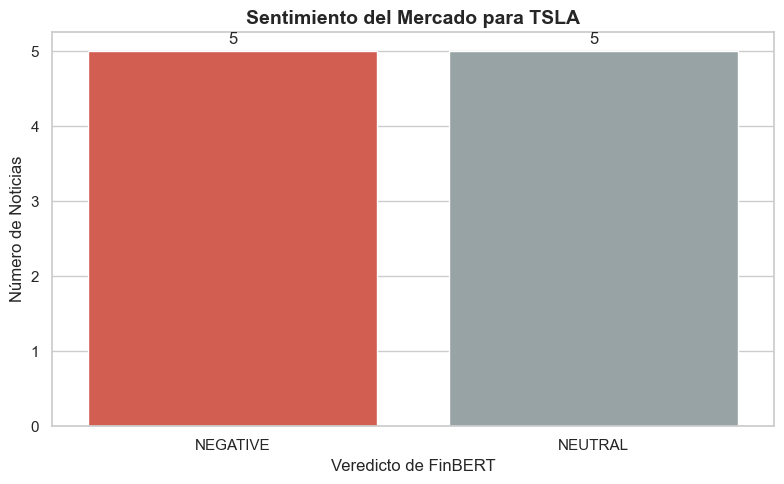

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Definición de los colores para cada sentimiento
colores = {
    "POSITIVE": "#2ecc71",  # Verde
    "NEGATIVE": "#e74c3c",  # Rojo
    "NEUTRAL":  "#95a5a6"   # Gris
}

# Contamos las noticias de cada tipo
conteo_sentimiento = df_noticias['Sentimiento'].value_counts()

# Creamos el gráfico de barras
ax = sns.barplot(
    x=conteo_sentimiento.index, 
    y=conteo_sentimiento.values, 
    palette=colores,
    hue=conteo_sentimiento.index,
    legend=False
)

# Añadimos etiquetas
plt.title(f"Sentimiento del Mercado para {ticker_empresa}", fontsize=14, fontweight='bold')
plt.ylabel("Número de Noticias", fontsize=12)
plt.xlabel("Veredicto de FinBERT", fontsize=12)

# Añadimos el número exacto encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points')

# Mostramos el resultado
plt.tight_layout()
plt.show()